# PS-S6E06: Model Blending


This notebook tackles the [**Playground Series – Season 6, Episode 6: Predicting Stellar Class**](https://www.kaggle.com/competitions/playground-series-s6e6), a competition focused on predicting a class label (`GALAXY`, `QSO`, `STAR`) for the `class` target, based on features describing the position, light intensity for various spectrums, and other features of the observation.

## Ensemble Strategy: Hill Climbing with Rank Normalization

We combine model outputs using a simple, effective hill-climbing ensemble (Caruana-style):

- Start from the best single model (highest OOF balanced accuracy)
- Iteratively add the model that improves the blended OOF balanced accuracy the most
- Convert selection counts into weights

Before blending, we apply **rank normalization** to each model's outputs. Rank transforms are monotonic, so they preserve AUC while putting models on a comparable scale.


## Install Needed Packages

(Usually not needed on Kaggle; keep this section only if you add extra dependencies.)


In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from itertools import product

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

from ps_s06e06_experiment_setup import ExperimentSetup
from ps_s06e06_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# Target column in the training dataset
TARGET = 'class'

Random seed set to: 10301
Warnings suppressed.


In [3]:
# Load training data and ground truth
training_df = helper.read_dataset('training')

# Encode target labels
target_mapping = {'QSO': 0, 'STAR': 1, 'GALAXY': 2}
y_true = training_df[TARGET].map(target_mapping).astype(int)

train_ids = training_df['id'].values

TRAINING DATASET

   id   alpha  delta      u      g      r      i      z  redshift  \
0   0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409   
1   1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158   
2   2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824   
3   3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536   
4   4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556   

  spectral_type galaxy_population   class  
0             M      Red_Sequence  GALAXY  
1             M      Red_Sequence  GALAXY  
2           O/B        Blue_Cloud     QSO  
3             M      Red_Sequence  GALAXY  
4             M      Red_Sequence  GALAXY  


In [4]:
# Sample submission (used to get correct submission column name and id order)
submission_df = helper.read_dataset('submission')
SUB_COL = [c for c in submission_df.columns if c != 'id'][0]

## Loading OOF and Test Probabilities

We load the out-of-fold (OOF) and test-set **probabilities** generated by individual model notebooks.

Expected file naming:
- `*_oof_probs.csv` contains columns: `id`, one probability column (e.g. `prob_xgb`), and optionally `target`
- `*_test_probs.csv` contains columns: `id` and one probability column

All files should share the same `id` values as the competition datasets.


In [5]:
oof_files = []
test_files = []

# Local convention: predictions stored under predictions/s06e06/
# Kaggle convention: mount dataset input that contains predictions/
if helper.running_in_kaggle():
    pred_dir = '/kaggle/input/notebooks/stephentarter/ps-s06e06-*/predictions'
else:
    pred_dir = 'predictions'

oof_files = sorted(glob.glob(f'{pred_dir}/*_oof_probs.csv'))
test_files = sorted(glob.glob(f'{pred_dir}/*_test_probs.csv'))

print(f'Found {len(oof_files)} OOF files and {len(test_files)} Test files.')
if len(oof_files) > 0:
    print('OOF files:')
    for f in oof_files:
        print(' -', os.path.basename(f))
if len(test_files) > 0:
    print('Test files:')
    for f in test_files:
        print(' -', os.path.basename(f))

Found 4 OOF files and 4 Test files.
OOF files:
 - catboost_oof_probs.csv
 - lgb_oof_probs.csv
 - nn_tabular_resnet_oof_probs.csv
 - xgb_oof_probs.csv
Test files:
 - catboost_test_probs.csv
 - lgb_test_probs.csv
 - nn_tabular_resnet_test_probs.csv
 - xgb_test_probs.csv


In [6]:
# Helper to load and merge probabilities
def load_probs(file_list, index_col='id'):
    df_list = []
    for file in file_list:
        base = os.path.basename(file)
        model_name = (
            base.replace('_oof_probs.csv', '')
                .replace('_test_probs.csv', '')
        )

        df = pd.read_csv(file)

        # Identify the probability column (exclude id/target)
        ignore = {'id', 'target', TARGET}
        prob_cols = [c for c in df.columns if c not in ignore]
        
        # Rename columns to include model name to avoid collisions
        # e.g., 'catboost_prob_qso', 'catboost_prob_star', etc.
        rename_map = {c: f"{model_name}_{c}" for c in prob_cols}

        # Set index and keep only the renamed prob columns
        subset = df.set_index(index_col).rename(columns=rename_map)[list(rename_map.values())]
        df_list.append(subset)

    # Join all models side-by-side
    return pd.concat(df_list, axis=1)

In [7]:
# Load OOF and Test probability tables
oof_df = load_probs(oof_files) if oof_files else pd.DataFrame()
test_df = load_probs(test_files) if test_files else pd.DataFrame()

# Align y_true to oof_df index via id
y_df = pd.DataFrame({'id': train_ids, 'target': y_true}).set_index('id')

common_ids = y_df.index.intersection(oof_df.index)
if len(common_ids) == 0:
    raise RuntimeError('No overlapping ids between training labels and OOF files.')

oof_df = oof_df.loc[common_ids].sort_index()
y_true_aligned = y_df.loc[oof_df.index, 'target'].values

# Align test_df to submission id order (if available)
if not test_df.empty:
    test_df = test_df.loc[submission_df['id'].values].copy()

print('OOF shape:', oof_df.shape)
print('Test shape:', test_df.shape)

OOF shape: (577347, 12)
Test shape: (247435, 12)


In [8]:
def drop_bad_models(oof_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    Drop any model column that has NaNs in OOF or Test.
    Then restrict to the intersection of model columns across OOF/Test.
    """
    bad = set()

    if not oof_df.empty:
        bad |= set(oof_df.columns[oof_df.isna().any(axis=0)])
    if not test_df.empty:
        bad |= set(test_df.columns[test_df.isna().any(axis=0)])

    if bad:
        print("Dropping models with missing values:", sorted(bad))
        oof_df = oof_df.drop(columns=[c for c in bad if c in oof_df.columns], errors="ignore")
        test_df = test_df.drop(columns=[c for c in bad if c in test_df.columns], errors="ignore")

    if test_df.empty:
        common = list(oof_df.columns)
    else:
        common = [c for c in oof_df.columns if c in test_df.columns]

    if not common:
        raise RuntimeError("No common model columns remain after dropping bad models.")

    oof_df = oof_df[common]
    if not test_df.empty:
        test_df = test_df[common]

    return oof_df, test_df

oof_df, test_df = drop_bad_models(oof_df, test_df)

print("Final model set:", list(oof_df.columns))
print("OOF shape:", oof_df.shape, "Test shape:", test_df.shape)

Final model set: ['catboost_prob_qso', 'catboost_prob_star', 'catboost_prob_galaxy', 'lgb_prob_qso', 'lgb_prob_star', 'lgb_prob_galaxy', 'nn_tabular_resnet_prob_qso', 'nn_tabular_resnet_prob_star', 'nn_tabular_resnet_prob_galaxy', 'xgb_prob_qso', 'xgb_prob_star', 'xgb_prob_galaxy']
OOF shape: (577347, 12) Test shape: (247435, 12)


In [9]:
oof_processed = oof_df.copy()
test_processed = test_df.copy()

print('\nIndividual Model Performance (OOF):')
best_single_model = None
best_single_score = -np.inf

# We assume oof_processed has columns like 'catboost_prob_qso', 'lgbm_prob_star', etc.
# To score a single model, we need to group its 3 probability columns.
model_names = list(set([c.split('_prob_')[0] for c in oof_processed.columns]))

model_preds = {}
model_scores = {}

for model in model_names:
    # Identify the 3 columns for this specific model
    cols = [f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"]
    model_probs = oof_processed[cols].values
    
    # Calculate Balanced Accuracy (The Competition Metric)
    # We take the argmax of the probabilities to get class labels 0, 1, or 2
    preds = np.argmax(model_probs, axis=1)
    model_preds[model] = preds
    score = balanced_accuracy_score(y_true_aligned, preds)
    model_scores[model] = score
    print(f'{model}: {score:.6f}')

    if score > best_single_score:
        best_single_score = score
        best_single_model = model

print(f'\nBest model/Score: {best_single_model}/{best_single_score:.6f}')


Individual Model Performance (OOF):
nn_tabular_resnet: 0.957739
lgb: 0.964197
catboost: 0.965156
xgb: 0.965754

Best model/Score: xgb/0.965754


In [10]:
print("Models loaded:", list(oof_processed.columns))
print("OOF files:", [os.path.basename(f) for f in oof_files])

Models loaded: ['catboost_prob_qso', 'catboost_prob_star', 'catboost_prob_galaxy', 'lgb_prob_qso', 'lgb_prob_star', 'lgb_prob_galaxy', 'nn_tabular_resnet_prob_qso', 'nn_tabular_resnet_prob_star', 'nn_tabular_resnet_prob_galaxy', 'xgb_prob_qso', 'xgb_prob_star', 'xgb_prob_galaxy']
OOF files: ['catboost_oof_probs.csv', 'lgb_oof_probs.csv', 'nn_tabular_resnet_oof_probs.csv', 'xgb_oof_probs.csv']


Models remaining after de-dup: ['nn_tabular_resnet', 'lgb', 'catboost', 'xgb']


,nn_tabular_resnet,lgb,catboost,xgb
nn_tabular_resnet,1.000,0.971,0.971,0.972
lgb,0.971,1.000,0.982,0.988
catboost,0.971,0.982,1.000,0.985
xgb,0.972,0.988,0.985,1.000


<Axes: >

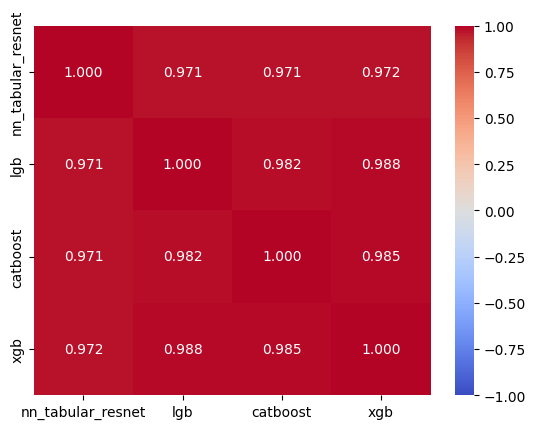

In [11]:
# Calculate final predictions and scores for each model
# Build a correlation matrix of the PREDICTIONS
# We use Spearman correlation on the class labels to see how similarly models "vote"
pred_df = pd.DataFrame(model_preds)
corr = pred_df.corr(method="spearman")

# Identify near-duplicate models
threshold = 0.995
to_drop_models = set()
cols = sorted(list(corr.columns))

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        if a in to_drop_models or b in to_drop_models:
            continue
            
        if corr.loc[a, b] >= threshold:
            # Drop the one with the lower Balanced Accuracy
            drop = b if model_scores[a] >= model_scores[b] else a
            to_drop_models.add(drop)

# Drop the model groups (all 3 columns) from the dataframes
if to_drop_models:
    print(f"Dropping {len(to_drop_models)} models (rho >= {threshold}):", sorted(to_drop_models))
    
    # Identify all columns associated with the dropped models
    cols_to_drop = []
    for model in to_drop_models:
        cols_to_drop.extend([f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"])
        
    oof_df = oof_df.drop(columns=cols_to_drop)
    test_df = test_df.drop(columns=cols_to_drop)

# Final display
print("Models remaining after de-dup:", list(set([c.split('_prob_')[0] for c in oof_df.columns if '_prob_' in c])))
display(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')

## Hill Climbing Algorithm

We search for a weighted ensemble that maximizes OOF balanced accuracy. At each iteration we add the single model that most improves the blended balanced accuracy.


In [12]:
# Hill Climbing Algorithm (Caruana-style)
# Iteratively adds the model that maximizes the ensemble ROC AUC
def hill_climbing(oof_df: pd.DataFrame, y: np.ndarray, iterations: int = 200, verbose: bool = False):
    model_names = list(set([c.split('_prob_')[0] for c in oof_df.columns if '_prob_' in c]))

    model_matrices = {}
    for model in model_names:
        cols = [f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"]
        model_matrices[model] = oof_df[cols].values

    # Find the best single model based on Balanced Accuracy
    best_single_model = None
    best_single_score = -np.inf
    
    for model in model_names:
        preds = np.argmax(model_matrices[model], axis=1)
        score = balanced_accuracy_score(y, preds)
        if score > best_single_score:
            best_single_score = score
            best_single_model = model

    # Initialize ensemble with the best single model
    # current_sum is an (N, 3) matrix
    current_sum = model_matrices[best_single_model].copy()
    k = 1

    model_counts = {m: 0 for m in model_names}
    model_counts[best_single_model] = 1
    history = [best_single_score]

    print(f'Starting Multi-class Hill Climbing for {iterations} iterations...')
    print(f'Starting from: {best_single_model} (Balanced Acc={best_single_score:.6f})')
    
    # Iterative addition
    for i in range(iterations):
        best_step_score = -np.inf
        best_step_model = None

        for model in model_names:
            # Average the N x 3 matrices
            temp_avg = (current_sum + model_matrices[model]) / (k + 1)
            
            # Convert soft probabilities to hard labels via argmax
            temp_preds = np.argmax(temp_avg, axis=1)
            
            # Score using the competition metric
            score = balanced_accuracy_score(y, temp_preds)

            if score > best_step_score:
                best_step_score = score
                best_step_model = model

        # Update ensemble with the winner of this round
        current_sum += model_matrices[best_step_model]
        k += 1
        model_counts[best_step_model] += 1
        history.append(best_step_score)

        if verbose and ((i + 1) % 10 == 0):
            print(f'Iter {i+1}: +{best_step_model} -> Balanced Acc {best_step_score:.6f}')

    # Calculate final weights
    total = sum(model_counts.values())
    weights = {m: c / total for m, c in model_counts.items() if c > 0}
    
    return weights, history

In [13]:
# Run Optimization
weights, history = hill_climbing(oof_processed, y_true_aligned, iterations=500, verbose=True)

print('\nFinal Weights:')
for m, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f'{m}: {w:.4f}')

print(f'\nFinal blended Balanced Acc: {history[-1]:.6f}')

Starting Multi-class Hill Climbing for 500 iterations...
Starting from: xgb (Balanced Acc=0.965754)
Iter 10: +xgb -> Balanced Acc 0.965848
Iter 20: +catboost -> Balanced Acc 0.965811
Iter 30: +catboost -> Balanced Acc 0.965846
Iter 40: +xgb -> Balanced Acc 0.965838
Iter 50: +xgb -> Balanced Acc 0.965830
Iter 60: +xgb -> Balanced Acc 0.965836
Iter 70: +catboost -> Balanced Acc 0.965835
Iter 80: +xgb -> Balanced Acc 0.965837
Iter 90: +catboost -> Balanced Acc 0.965832
Iter 100: +xgb -> Balanced Acc 0.965826
Iter 110: +xgb -> Balanced Acc 0.965834
Iter 120: +catboost -> Balanced Acc 0.965844
Iter 130: +nn_tabular_resnet -> Balanced Acc 0.965837
Iter 140: +xgb -> Balanced Acc 0.965847
Iter 150: +xgb -> Balanced Acc 0.965848
Iter 160: +xgb -> Balanced Acc 0.965834
Iter 170: +xgb -> Balanced Acc 0.965831
Iter 180: +catboost -> Balanced Acc 0.965833
Iter 190: +nn_tabular_resnet -> Balanced Acc 0.965845
Iter 200: +xgb -> Balanced Acc 0.965839
Iter 210: +xgb -> Balanced Acc 0.965841
Iter 220: +

In [14]:
print("OOF columns:", list(oof_df.columns))
print("TEST columns:", list(test_df.columns))

OOF columns: ['catboost_prob_qso', 'catboost_prob_star', 'catboost_prob_galaxy', 'lgb_prob_qso', 'lgb_prob_star', 'lgb_prob_galaxy', 'nn_tabular_resnet_prob_qso', 'nn_tabular_resnet_prob_star', 'nn_tabular_resnet_prob_galaxy', 'xgb_prob_qso', 'xgb_prob_star', 'xgb_prob_galaxy']
TEST columns: ['catboost_prob_qso', 'catboost_prob_star', 'catboost_prob_galaxy', 'lgb_prob_qso', 'lgb_prob_star', 'lgb_prob_galaxy', 'nn_tabular_resnet_prob_qso', 'nn_tabular_resnet_prob_star', 'nn_tabular_resnet_prob_galaxy', 'xgb_prob_qso', 'xgb_prob_star', 'xgb_prob_galaxy']


### Plot Convergence

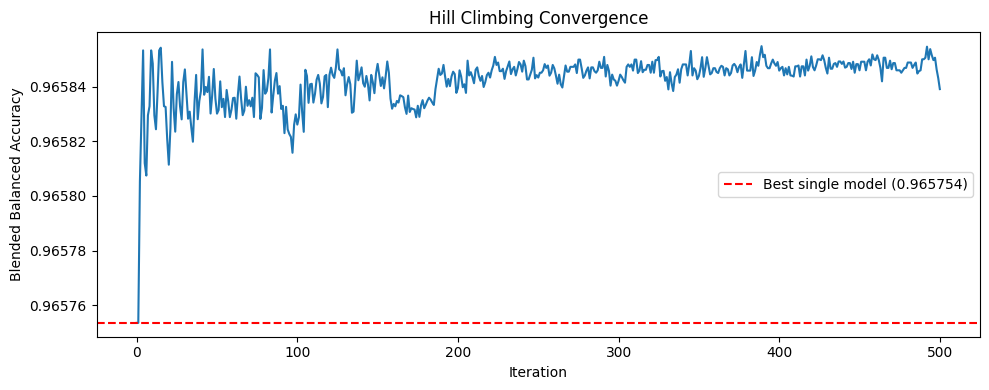

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel('Blended Balanced Accuracy')
plt.title('Hill Climbing Convergence')
plt.axhline(best_single_score, color='red', linestyle='--', label=f'Best single model ({best_single_score:.6f})')
plt.legend()
plt.tight_layout()
plt.show()

### Verify the hill-climbing result is globally optimal

In [16]:
best_score, best_w = -np.inf, None
step = 0.05
candidates = [round(i * step, 2) for i in range(int(1/step) + 1)]

for w1, w2, w3 in product(candidates, repeat=3):
    w4 = round(1.0 - w1 - w2 - w3, 2)
    if w4 < 0 or w4 > 1:
        continue

    weights_try = {'xgb': w1, 'lgb': w2, 'catboost': w3, 'nn_tabular_resnet': w4}
    blended = sum(
        oof_processed[[f'{m}_prob_qso', f'{m}_prob_star', f'{m}_prob_galaxy']].values * w
        for m, w in weights_try.items()
    )
    score = balanced_accuracy_score(y_true_aligned, np.argmax(blended, axis=1))
    if score > best_score:
        best_score, best_w = score, weights_try.copy()

print(f'Grid search best: {best_score:.6f} with weights {best_w}')

Grid search best: 0.965853 with weights {'xgb': 0.8, 'lgb': 0.0, 'catboost': 0.2, 'nn_tabular_resnet': -0.0}


## Final Ensemble & Submission

We apply the learned weights to both OOF and test probabilities, then write a submission file using the competition’s sample submission schema.


In [17]:
# Blend OOF probabilities (weighted average)
blend_oof_probs = np.zeros((len(oof_df), 3), dtype=np.float64)

# Blend the N x 3 matrices for each model
for model, w in weights.items():
    # Identify the three probability columns for this model
    cols = [f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"]
    
    # Add the weighted probability matrix to the total
    blend_oof_probs += oof_df[cols].to_numpy(dtype=np.float64) * float(w)

# Generate final predictions using Argmax
blend_preds = np.argmax(blend_oof_probs, axis=1)

# Calculate Balanced Accuracy (Competition Metric)
blend_score = balanced_accuracy_score(y_true_aligned, blend_preds)

print(f'Blended OOF Balanced Accuracy: {blend_score:.6f}')

Blended OOF Balanced Accuracy: 0.965839


In [18]:
## Graph Results

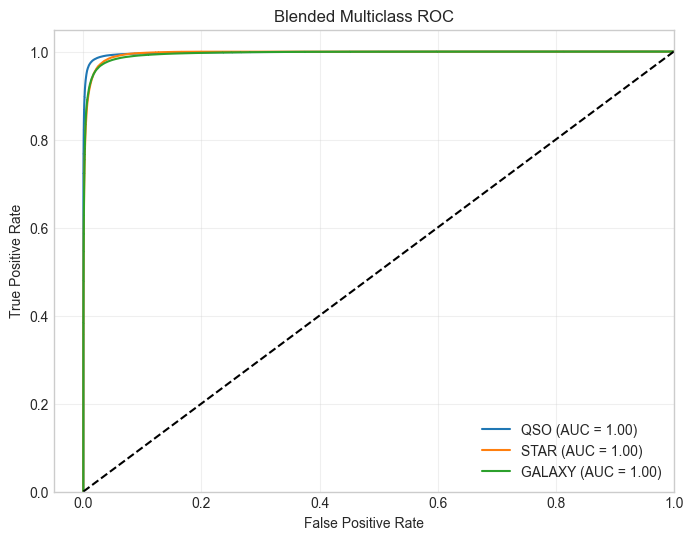

In [19]:
from ps_s06e06_model_visualizer import ModelVisualizer

mviz = ModelVisualizer(model_name='Blended')

class_names = ['QSO (0)', 'STAR (1)', 'GALAXY (2)']

mviz.plot_multiclass_roc_curve(y_true=y_true_aligned, y_score=blend_oof_probs,
                                title='Blended Multiclass ROC')


Normalized confusion matrix


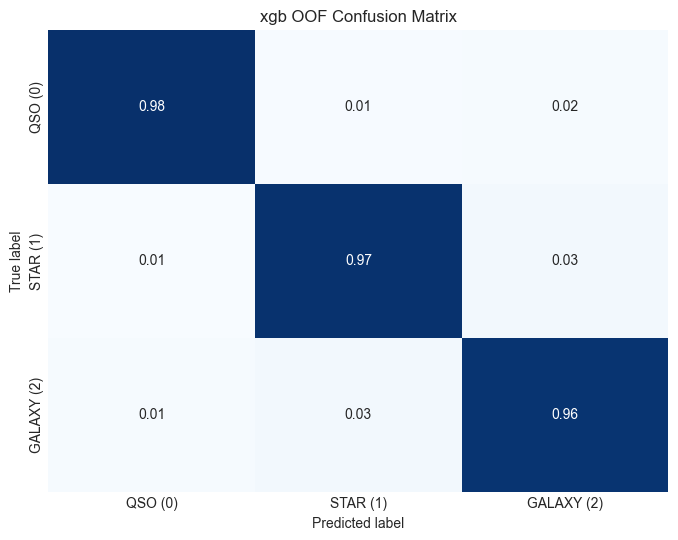

In [20]:
# Best single model vs. blend, side by side
mviz.plot_confusion_matrix(y_true_aligned, model_preds[best_single_model],
                            classes=class_names, normalize=True,
                            title=f'{best_single_model} OOF Confusion Matrix')


Normalized confusion matrix


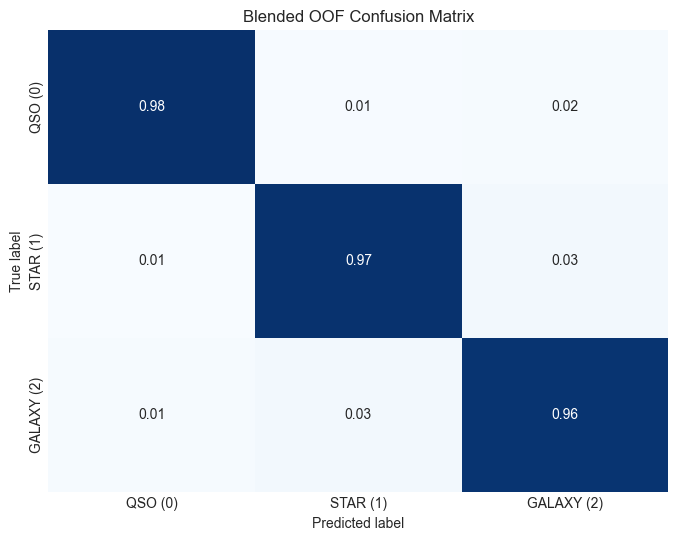

In [21]:
mviz.plot_confusion_matrix(y_true_aligned, blend_preds,
                            classes=class_names, normalize=True,
                            title='Blended OOF Confusion Matrix')


In [22]:
# Initialize an N x 3 matrix to hold the weighted test probabilities
# We use the raw test_df instead of test_ranked to maintain class-wise integrity
final_test_probs = np.zeros((len(test_df), 3), dtype=np.float64)

print("Applying model weights to Test set probabilities...")

for model, weight in weights.items():
    # Identify the three probability columns for this model
    cols = [f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"]
    
    # Add weighted matrix to the ensemble total
    final_test_probs += test_df[cols].to_numpy(dtype=np.float64) * float(weight)

# Convert blended probabilities to final class labels using Argmax
# This picks the stellar class (0=QSO, 1=STAR, 2=GALAXY) with the highest total confidence
final_predictions = np.argmax(final_test_probs, axis=1)

# Prepare the final submission DataFrame
out = submission_df.copy()
out[TARGET] = final_predictions

reverse_mapping = {v: k for k, v in target_mapping.items()}
out[TARGET] = out[TARGET].map(reverse_mapping)

# Save to CSV
out.to_csv('submission.csv', index=False)
print('\nSaved: submission.csv')

print('\nSUBMISSION PREVIEW')
print('==================')
print(out.head(10))

# Class Distribution Check
# Useful to see if the ensemble is predicting all three classes
print('\nPredicted Class Distribution:')
print(out[TARGET].value_counts(normalize=True).sort_index())

Applying model weights to Test set probabilities...

Saved: submission.csv

SUBMISSION PREVIEW
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
5  577352  GALAXY
6  577353  GALAXY
7  577354    STAR
8  577355  GALAXY
9  577356  GALAXY

Predicted Class Distribution:
class
GALAXY   0.634
QSO      0.208
STAR     0.158
Name: proportion, dtype: float64
